In [1]:
!pip install -q tensorflow==2.21.0 keras==3.15.1 keras-hub==0.32.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 MB 8.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.20.1 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.21.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incomp

In [2]:
import tensorflow as tf
import keras
import keras_hub

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("KerasHub:", keras_hub.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
Keras: 3.15.1
KerasHub: 0.32.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from pathlib import Path

print("My Drive contents:")
for p in Path("/content/drive/MyDrive").iterdir():
    print(p)

My Drive contents:
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/Snapchat-1192624498.jpg
/content/drive/MyDrive/20221110_191429.jpg
/content/drive/MyDrive/IMG-20230202-WA0014.jpg
/content/drive/MyDrive/20230204_205612.jpg
/content/drive/MyDrive/News_Aggregator_Design_Review_Notice_copy.pdf
/content/drive/MyDrive/python 4.pdf
/content/drive/MyDrive/Sandeep_Tharala_Resume (7).pdf
/content/drive/MyDrive/Sandeep_Tharala_Resume (6).pdf
/content/drive/MyDrive/Sandeep_Tharala_Resume (5).pdf
/content/drive/MyDrive/Sandeep_Tharala_Resume (4).pdf
/content/drive/MyDrive/Sandeep_Tharala_Resume (1) (1).pdf
/content/drive/MyDrive/Placement material
/content/drive/MyDrive/20 rupee doge.gdoc
/content/drive/MyDrive/20 rupee doge.pdf
/content/drive/MyDrive/20 rupee doge (1).docx
/content/drive/MyDrive/20 rupee doge.docx
/content/drive/MyDrive/sandeep-jntuh-memo-1st to 6th sem.pdf
/content/drive/MyDrive/Artificial Neural Networks (ANNs).gslides
/content/drive/MyDrive/myimg.jpg
/content/dr

In [5]:
from pathlib import Path

NUTRIVISION = Path("/content/drive/MyDrive/NutriVision")

required = [
    "gate3_500.zip",
    "manifest.csv",
    "class_statistics.csv",
]

for name in required:
    path = NUTRIVISION / name
    print(name, "->", path.exists())

gate3_500.zip -> True
manifest.csv -> True
class_statistics.csv -> True


In [6]:
import tensorflow as tf
import keras
import keras_hub

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("KerasHub:", keras_hub.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
Keras: 3.15.1
KerasHub: 0.32.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
from pathlib import Path

gate3 = Path("/content/gate3_500")

print("Gate 3 directory exists:", gate3.exists())
print("Images:", len(list((gate3 / "images").glob("*.jpg"))))
print("Masks :", len(list((gate3 / "masks").glob("*.png"))))

Gate 3 directory exists: False
Images: 0
Masks : 0


In [11]:
from pathlib import Path

matches = list(Path("/content/drive").rglob("gate3_500.zip"))

print("Found:", len(matches))

for p in matches:
    print(p)

Found: 1
/content/drive/MyDrive/NutriVision/gate3_500.zip


In [14]:
from pathlib import Path
import shutil

root = Path("/content/gate3_500")

images_dir = root / "images"
masks_dir = root / "masks"

images_dir.mkdir(exist_ok=True)
masks_dir.mkdir(exist_ok=True)

moved_images = 0
moved_masks = 0

for p in list(root.iterdir()):
    if not p.is_file():
        continue

    name = p.name

    if name.startswith("images\\") and name.endswith(".jpg"):
        filename = name.split("\\", 1)[1]
        shutil.move(str(p), str(images_dir / filename))
        moved_images += 1

    elif name.startswith("masks\\") and name.endswith(".png"):
        filename = name.split("\\", 1)[1]
        shutil.move(str(p), str(masks_dir / filename))
        moved_masks += 1

print("Moved images:", moved_images)
print("Moved masks :", moved_masks)

print("\nFinal:")
print("Images:", len(list(images_dir.glob("*.jpg"))))
print("Masks :", len(list(masks_dir.glob("*.png"))))

Moved images: 500
Moved masks : 500

Final:
Images: 500
Masks : 500


In [15]:
from pathlib import Path
import numpy as np
from PIL import Image

root = Path("/content/gate3_500")
images_dir = root / "images"
masks_dir = root / "masks"

image_files = sorted(images_dir.glob("*.jpg"))
mask_files = sorted(masks_dir.glob("*.png"))

assert len(image_files) == 500
assert len(mask_files) == 500

# ------------------------------------------------------------
# Build image -> mask mapping
# ------------------------------------------------------------

mask_map = {p.stem: p for p in mask_files}

pairs = []

for image_path in image_files:
    mask_path = mask_map.get(image_path.stem)

    if mask_path is None:
        raise FileNotFoundError(
            f"No mask found for {image_path.name}"
        )

    pairs.append((image_path, mask_path))

# ------------------------------------------------------------
# Determine classes present in each image
# ------------------------------------------------------------

image_classes = []

for image_path, mask_path in pairs:
    mask = np.asarray(Image.open(mask_path), dtype=np.uint8)

    classes = set(np.unique(mask).tolist())
    classes.discard(0)  # remove background

    image_classes.append(classes)

# ------------------------------------------------------------
# Reproduce a class-covered 400/100 split
#
# We select 100 held-out images while ensuring every food
# class appearing in the 500-image dataset remains represented
# in the 400-image training set.
# ------------------------------------------------------------

all_classes = set().union(*image_classes)

rng = np.random.default_rng(42)

indices = np.arange(len(pairs))
rng.shuffle(indices)

eval_indices = []
train_indices = []

# Start with an empty evaluation set.
# Add an image only if removing it still leaves every class
# represented by at least one remaining training image.

class_total_counts = {
    c: sum(c in classes for classes in image_classes)
    for c in all_classes
}

remaining_counts = class_total_counts.copy()

for idx in indices:
    if len(eval_indices) >= 100:
        break

    classes = image_classes[idx]

    # Can this image be moved to evaluation without removing
    # the last training occurrence of any class?
    safe = all(
        remaining_counts[c] > 1
        for c in classes
    )

    if safe:
        eval_indices.append(idx)

        for c in classes:
            remaining_counts[c] -= 1

eval_indices = sorted(eval_indices)

if len(eval_indices) != 100:
    raise RuntimeError(
        f"Could only construct {len(eval_indices)} held-out images."
    )

eval_set = set(eval_indices)
train_indices = [
    i for i in range(len(pairs))
    if i not in eval_set
]

assert len(train_indices) == 400
assert len(set(train_indices) & set(eval_indices)) == 0

# ------------------------------------------------------------
# Verify class coverage
# ------------------------------------------------------------

train_classes = set().union(
    *(image_classes[i] for i in train_indices)
)

eval_classes = set().union(
    *(image_classes[i] for i in eval_indices)
)

heldout_only = eval_classes - train_classes

print("===== SPLIT RESULT =====")
print("Train images :", len(train_indices))
print("Eval images  :", len(eval_indices))
print("Overlap      :", len(set(train_indices) & set(eval_indices)))

print("\nTrain classes:", len(train_classes))
print("Eval classes :", len(eval_classes))
print("Held-out-only classes:", sorted(heldout_only))

assert len(heldout_only) == 0

# ------------------------------------------------------------
# Save split files
# ------------------------------------------------------------

split_dir = Path("/content/gate3_split")
split_dir.mkdir(exist_ok=True)

with open(split_dir / "train.txt", "w") as f:
    for i in train_indices:
        f.write(pairs[i][0].name + "\n")

with open(split_dir / "eval.txt", "w") as f:
    for i in eval_indices:
        f.write(pairs[i][0].name + "\n")

print("\nSaved:")
print(split_dir / "train.txt")
print(split_dir / "eval.txt")

===== SPLIT RESULT =====
Train images : 400
Eval images  : 100
Overlap      : 0

Train classes: 82
Eval classes : 65
Held-out-only classes: []

Saved:
/content/gate3_split/train.txt
/content/gate3_split/eval.txt


In [17]:
# ============================================================
# GATE 3R — FIX DATASET PATH HANDLING
# ============================================================

IMAGE_DIR_STR = str(IMAGE_DIR)
MASK_DIR_STR = str(MASK_DIR)

def load_pair(filename):
    # filename is a Tensor inside tf.data
    image_path = tf.strings.join(
        [IMAGE_DIR_STR, "/", filename]
    )

    mask_filename = tf.strings.regex_replace(
        filename,
        r"\.jpg$",
        ".png"
    )

    mask_path = tf.strings.join(
        [MASK_DIR_STR, "/", mask_filename]
    )

    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)

    image = tf.image.resize(
        image,
        IMAGE_SIZE,
        method="bilinear",
    )

    mask = tf.image.resize(
        mask,
        IMAGE_SIZE,
        method="nearest",
    )

    image = tf.cast(image, tf.float32)
    mask = tf.cast(mask[..., 0], tf.int32)

    # Exact SegFormer preprocessing from P1
    image = image * SCALE + OFFSET

    return image, mask


def make_dataset(names, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(names)

    if shuffle:
        ds = ds.shuffle(
            len(names),
            seed=42,
            reshuffle_each_iteration=True,
        )

    ds = ds.map(
        load_pair,
        num_parallel_calls=tf.data.AUTOTUNE,
    )

    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


train_ds = make_dataset(train_names, shuffle=True)
eval_ds = make_dataset(eval_names, shuffle=False)

print("Dataset objects created successfully.")

# CPU/lightweight data check — no model training
train_images, train_masks = next(iter(train_ds))

print("Train batch images:", train_images.shape, train_images.dtype)
print("Train batch masks :", train_masks.shape, train_masks.dtype)
print("Image range:", float(tf.reduce_min(train_images)),
      "to", float(tf.reduce_max(train_images)))
print("Mask classes:", tf.unique(tf.reshape(train_masks, [-1]))[0].numpy()[:20])

Dataset objects created successfully.
Train batch images: (4, 512, 512, 3) <dtype: 'float32'>
Train batch masks : (4, 512, 512) <dtype: 'int32'>
Image range: -2.1179039478302 to 2.6399998664855957
Mask classes: [ 0 85 73 94 52 58 80 71 46 67 30 24 31  5 20]


In [19]:
# ============================================================
# GATE 3R — CREATE THE MODEL
# No training
# ============================================================

import keras_hub

NUM_CLASSES = 104

print("Loading SegFormer B2...")

model = keras_hub.models.SegFormerImageSegmenter.from_preset(
    "segformer_b2_ade20k_512",
    num_classes=NUM_CLASSES,
)

print("\nModel created successfully.")
print("Model type:", type(model).__name__)
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)

Loading SegFormer B2...


100%|██████████| 1.66k/1.66k [00:00<00:00, 2.48MB/s]


100%|██████████| 4.71k/4.71k [00:00<00:00, 9.18MB/s]



Model created successfully.
Model type: SegFormerImageSegmenter
Input shape: (None, 512, 512, 3)
Output shape: (None, 512, 512, 104)


In [20]:
# ============================================================
# GATE 3R — CONTROLLED TRAINING
# Maximum: 5 epochs
# Validation after every epoch
# ============================================================

import time
import numpy as np
import tensorflow as tf

print("===== GATE 3R — STARTING TRAINING =====")

# ------------------------------------------------------------
# Fresh optimizer and loss
# ------------------------------------------------------------

loss_fn_gate3r = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

optimizer_gate3r = tf.keras.optimizers.AdamW(
    learning_rate=1e-4,
    weight_decay=0.01,
    global_clipnorm=1.0,
)

# ------------------------------------------------------------
# Compiled training step
# ------------------------------------------------------------

@tf.function
def gate3r_train_step(images, masks):

    with tf.GradientTape() as tape:

        logits = model(
            images,
            training=True
        )

        loss = loss_fn_gate3r(
            masks,
            logits
        )

    gradients = tape.gradient(
        loss,
        model.trainable_variables
    )

    optimizer_gate3r.apply_gradients(
        zip(
            gradients,
            model.trainable_variables
        )
    )

    return loss


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

def gate3r_evaluate(dataset):

    total_correct = 0
    total_pixels = 0

    intersections = np.zeros(
        NUM_CLASSES,
        dtype=np.int64
    )

    unions = np.zeros(
        NUM_CLASSES,
        dtype=np.int64
    )

    total_loss = 0.0
    batches = 0

    for images, masks in dataset:

        logits = model(
            images,
            training=False
        )

        loss = loss_fn_gate3r(
            masks,
            logits
        )

        predictions = tf.argmax(
            logits,
            axis=-1,
            output_type=tf.int32
        )

        y_true = masks.numpy()
        y_pred = predictions.numpy()

        total_correct += np.sum(
            y_true == y_pred
        )

        total_pixels += y_true.size

        total_loss += float(loss.numpy())
        batches += 1

        for class_id in range(NUM_CLASSES):

            true_pixels = y_true == class_id
            pred_pixels = y_pred == class_id

            intersections[class_id] += np.sum(
                true_pixels & pred_pixels
            )

            unions[class_id] += np.sum(
                true_pixels | pred_pixels
            )

    pixel_accuracy = (
        total_correct / total_pixels
    )

    valid_classes = unions > 0

    miou = np.mean(
        intersections[valid_classes] /
        unions[valid_classes]
    )

    return (
        pixel_accuracy,
        miou,
        total_loss / batches
    )


# ------------------------------------------------------------
# Training loop
# ------------------------------------------------------------

MAX_EPOCHS = 5

for epoch in range(1, MAX_EPOCHS + 1):

    epoch_start = time.time()

    total_train_loss = 0.0
    train_steps = 0

    print(f"\n===== Epoch {epoch}/{MAX_EPOCHS} =====")

    for images, masks in train_ds:

        loss = gate3r_train_step(
            images,
            masks
        )

        total_train_loss += float(loss.numpy())
        train_steps += 1

        if train_steps % 25 == 0:
            print(
                f"Step {train_steps} "
                f"| train loss "
                f"{total_train_loss / train_steps:.4f}"
            )

    train_loss = (
        total_train_loss / train_steps
    )

    val_accuracy, val_miou, val_loss = (
        gate3r_evaluate(eval_ds)
    )

    elapsed = time.time() - epoch_start

    print(
        f"Epoch {epoch} summary:"
    )

    print(
        f"  Train loss       : {train_loss:.4f}"
    )

    print(
        f"  Validation loss  : {val_loss:.4f}"
    )

    print(
        f"  Validation pixel accuracy : "
        f"{val_accuracy:.4f}"
    )

    print(
        f"  Validation mIoU : "
        f"{val_miou:.4f}"
    )

    print(
        f"  Time             : "
        f"{elapsed:.1f} sec"
    )

print("\n===== GATE 3R COMPLETE =====")

===== GATE 3R — STARTING TRAINING =====

===== Epoch 1/5 =====
Step 25 | train loss 3.7868
Step 50 | train loss 3.2503
Step 75 | train loss 2.9724
Step 100 | train loss 2.7851
Epoch 1 summary:
  Train loss       : 2.7851
  Validation loss  : 1.8407
  Validation pixel accuracy : 0.6059
  Validation mIoU : 0.0366
  Time             : 184.0 sec

===== Epoch 2/5 =====
Step 25 | train loss 1.9357


KeyboardInterrupt: 

In [25]:
from pathlib import Path

drive_root = Path("/content/drive")

matches = []

for p in drive_root.rglob("foodseg103_segmentation"):
    if p.is_dir():
        matches.append(p)

print("Found folders:", len(matches))

for p in matches:
    print(p)

Found folders: 0


In [35]:
from pathlib import Path

p = Path("/content/drive/MyDrive/NutriVision/foodseg103_segmentation.zip")

print("Exists:", p.exists())

if p.exists():
    print("Bytes:", p.stat().st_size)
    print("GB:", round(p.stat().st_size / (1024**3), 3))

Exists: True
Bytes: 1390379699
GB: 1.295


In [36]:
from pathlib import Path
import zipfile
import shutil

zip_path = Path(
    "/content/drive/MyDrive/NutriVision/foodseg103_segmentation.zip"
)

extract_root = Path("/content/nutrition_training_data")

# Remove only a previous partial extraction, if any
if extract_root.exists():
    shutil.rmtree(extract_root)

extract_root.mkdir(parents=True, exist_ok=True)

print("Extracting production dataset...")
print("This may take a few minutes because the archive is ~1.3 GB.")

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_root)

dataset_root = (
    extract_root /
    "data" /
    "processed" /
    "foodseg103_segmentation"
)

print("\nExtraction complete.")
print("Dataset path:", dataset_root)
print("Exists:", dataset_root.exists())

print("\nExpected folders:")
for name in ["images", "masks"]:
    path = dataset_root / name
    print(name, "->", path.exists())

Extracting production dataset...
This may take a few minutes because the archive is ~1.3 GB.

Extraction complete.
Dataset path: /content/nutrition_training_data/data/processed/foodseg103_segmentation
Exists: False

Expected folders:
images -> False
masks -> False


In [37]:
from pathlib import Path

root = Path("/content/nutrition_training_data")

print("Top-level extracted entries:")
for p in root.iterdir():
    print(repr(str(p)))

print("\nFirst 20 directories/files:")
for p in list(root.rglob("*"))[:20]:
    print(repr(str(p)))

Top-level extracted entries:
'/content/nutrition_training_data/foodseg103_segmentation\\masks\\train\\03273.png'
'/content/nutrition_training_data/foodseg103_segmentation\\images\\train\\02937.jpg'
'/content/nutrition_training_data/foodseg103_segmentation\\images\\train\\04631.jpg'
'/content/nutrition_training_data/foodseg103_segmentation\\masks\\train\\03603.png'
'/content/nutrition_training_data/foodseg103_segmentation\\images\\val\\01979.jpg'
'/content/nutrition_training_data/foodseg103_segmentation\\images\\train\\01221.jpg'
'/content/nutrition_training_data/foodseg103_segmentation\\masks\\val\\00185.png'
'/content/nutrition_training_data/foodseg103_segmentation\\images\\val\\01307.jpg'
'/content/nutrition_training_data/foodseg103_segmentation\\images\\train\\02402.jpg'
'/content/nutrition_training_data/foodseg103_segmentation\\images\\val\\01006.jpg'
'/content/nutrition_training_data/foodseg103_segmentation\\masks\\train\\00023.png'
'/content/nutrition_training_data/foodseg103_seg

In [38]:
from pathlib import Path
import shutil

root = Path("/content/nutrition_training_data")
fixed_root = root / "foodseg103_segmentation"

# Create the proper Linux directories
for split in ["train", "val"]:
    (fixed_root / "images" / split).mkdir(parents=True, exist_ok=True)
    (fixed_root / "masks" / split).mkdir(parents=True, exist_ok=True)

moved = {
    "images_train": 0,
    "images_val": 0,
    "masks_train": 0,
    "masks_val": 0,
}

# The incorrectly extracted files are direct children of root.
for p in list(root.iterdir()):

    if not p.is_file():
        continue

    name = p.name

    # images\train\xxxxx.jpg
    if name.startswith("foodseg103_segmentation\\images\\"):
        relative = name.split(
            "foodseg103_segmentation\\images\\",
            1
        )[1]

        parts = relative.split("\\", 1)

        if len(parts) == 2:
            split, filename = parts

            if split in ["train", "val"]:
                destination = (
                    fixed_root /
                    "images" /
                    split /
                    filename
                )

                shutil.move(str(p), str(destination))
                moved[f"images_{split}"] += 1

    # masks\train\xxxxx.png
    elif name.startswith("foodseg103_segmentation\\masks\\"):
        relative = name.split(
            "foodseg103_segmentation\\masks\\",
            1
        )[1]

        parts = relative.split("\\", 1)

        if len(parts) == 2:
            split, filename = parts

            if split in ["train", "val"]:
                destination = (
                    fixed_root /
                    "masks" /
                    split /
                    filename
                )

                shutil.move(str(p), str(destination))
                moved[f"masks_{split}"] += 1

print("Moved:")
for key, value in moved.items():
    print(f"{key}: {value}")

print("\nFinal counts:")

for split in ["train", "val"]:
    image_count = len(
        list((fixed_root / "images" / split).glob("*.jpg"))
    )

    mask_count = len(
        list((fixed_root / "masks" / split).glob("*.png"))
    )

    print(
        f"{split}: "
        f"images={image_count}, "
        f"masks={mask_count}"
    )

Moved:
images_train: 4979
images_val: 2134
masks_train: 4979
masks_val: 2134

Final counts:
train: images=4979, masks=4979
val: images=2134, masks=2134


In [39]:
# ============================================================
# PRODUCTION TRAINING — CREATE TRAIN / DEV SPLIT
# CPU / FILESYSTEM ONLY — NO MODEL, NO GPU TRAINING
# ============================================================

from pathlib import Path
import numpy as np

DATASET_ROOT = Path(
    "/content/nutrition_training_data/"
    "foodseg103_segmentation"
)

TRAIN_IMAGES = DATASET_ROOT / "images" / "train"
TRAIN_MASKS = DATASET_ROOT / "masks" / "train"

SPLIT_ROOT = Path("/content/production_split")
SPLIT_ROOT.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Collect all processed training images
# ------------------------------------------------------------

image_files = sorted(TRAIN_IMAGES.glob("*.jpg"))

assert len(image_files) == 4979, (
    f"Expected 4979 training images, "
    f"found {len(image_files)}"
)

# ------------------------------------------------------------
# Deterministic 90/10 split
# ------------------------------------------------------------

rng = np.random.default_rng(42)

indices = np.arange(len(image_files))
rng.shuffle(indices)

dev_size = 500

dev_indices = np.sort(indices[:dev_size])
train_indices = np.sort(indices[dev_size:])

assert len(train_indices) == 4479
assert len(dev_indices) == 500

# ------------------------------------------------------------
# Save filenames
# ------------------------------------------------------------

with open(SPLIT_ROOT / "train.txt", "w") as f:
    for idx in train_indices:
        f.write(image_files[idx].name + "\n")

with open(SPLIT_ROOT / "dev.txt", "w") as f:
    for idx in dev_indices:
        f.write(image_files[idx].name + "\n")

# ------------------------------------------------------------
# Basic checks
# ------------------------------------------------------------

train_set = set(image_files[i].name for i in train_indices)
dev_set = set(image_files[i].name for i in dev_indices)

print("===== PRODUCTION SPLIT =====")
print("Original processed train:", len(image_files))
print("Production train        :", len(train_set))
print("Development set         :", len(dev_set))
print("Overlap                 :", len(train_set & dev_set))

print("\nSaved:")
print(SPLIT_ROOT / "train.txt")
print(SPLIT_ROOT / "dev.txt")

assert len(train_set & dev_set) == 0

===== PRODUCTION SPLIT =====
Original processed train: 4979
Production train        : 4479
Development set         : 500
Overlap                 : 0

Saved:
/content/production_split/train.txt
/content/production_split/dev.txt


In [40]:
import tensorflow as tf
from pathlib import Path

# ============================================================
# PRODUCTION DATASET
# ============================================================

DATA_ROOT = Path("/content/nutrition_training_data/foodseg103_segmentation")
SPLIT_ROOT = Path("/content/production_split")

TRAIN_LIST = SPLIT_ROOT / "train.txt"
DEV_LIST   = SPLIT_ROOT / "dev.txt"

IMG_SIZE = 512
BATCH_SIZE = 4
NUM_CLASSES = 104

# SegFormer / KerasHub preprocessing verified earlier
MEAN = tf.constant(
    [0.485, 0.456, 0.406],
    dtype=tf.float32
)
STD = tf.constant(
    [0.229, 0.224, 0.225],
    dtype=tf.float32
)


def read_split_file(path):
    with open(path, "r", encoding="utf-8") as f:
        return [
            line.strip()
            for line in f
            if line.strip()
        ]


train_names = read_split_file(TRAIN_LIST)
dev_names   = read_split_file(DEV_LIST)

print("===== PRODUCTION DATASET =====")
print("Train samples:", len(train_names))
print("Dev samples  :", len(dev_names))


def make_dataset(names, training=False):
    image_paths = [
        str(DATA_ROOT / "images" / "train" / name)
        for name in names
    ]

    mask_paths = [
        str(DATA_ROOT / "masks" / "train" / name.replace(".jpg", ".png"))
        for name in names
    ]

    image_paths = tf.constant(image_paths)
    mask_paths = tf.constant(mask_paths)

    ds = tf.data.Dataset.from_tensor_slices(
        (image_paths, mask_paths)
    )

    if training:
        ds = ds.shuffle(
            buffer_size=len(names),
            seed=42,
            reshuffle_each_iteration=True
        )

    def load_example(image_path, mask_path):

        # Image: JPEG -> RGB -> float32
        image = tf.io.read_file(image_path)
        image = tf.image.decode_jpeg(
            image,
            channels=3
        )

        image = tf.image.resize(
            image,
            [IMG_SIZE, IMG_SIZE],
            method="bilinear"
        )

        image = tf.cast(image, tf.float32) / 255.0

        # SegFormer preprocessing
        image = (image - MEAN) / STD

        # Mask: PNG -> single channel integer class IDs
        mask = tf.io.read_file(mask_path)
        mask = tf.image.decode_png(
            mask,
            channels=1
        )

        mask = tf.image.resize(
            mask,
            [IMG_SIZE, IMG_SIZE],
            method="nearest"
        )

        mask = tf.cast(
            tf.squeeze(mask, axis=-1),
            tf.int32
        )

        return image, mask

    ds = ds.map(
        load_example,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.batch(
        BATCH_SIZE,
        drop_remainder=False
    )

    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


train_ds = make_dataset(
    train_names,
    training=True
)

dev_ds = make_dataset(
    dev_names,
    training=False
)

# ============================================================
# REQUIRED SANITY CHECK
# ============================================================

train_images, train_masks = next(iter(train_ds))
dev_images, dev_masks = next(iter(dev_ds))

print("\n===== SHAPES =====")
print("Train images:", train_images.shape)
print("Train masks :", train_masks.shape)
print("Dev images  :", dev_images.shape)
print("Dev masks   :", dev_masks.shape)

print("\n===== IMAGE RANGE =====")
print(
    "Train:",
    float(tf.reduce_min(train_images)),
    "to",
    float(tf.reduce_max(train_images))
)

print(
    "Dev  :",
    float(tf.reduce_min(dev_images)),
    "to",
    float(tf.reduce_max(dev_images))
)

print("\n===== MASK RANGE =====")
print(
    "Train:",
    int(tf.reduce_min(train_masks)),
    "to",
    int(tf.reduce_max(train_masks))
)

print(
    "Dev  :",
    int(tf.reduce_min(dev_masks)),
    "to",
    int(tf.reduce_max(dev_masks))
)

print("\n===== EXPECTED =====")
print("Images : (4, 512, 512, 3)")
print("Masks  : (4, 512, 512)")
print("Image normalization: approximately -2.12 to +2.64")
print("Mask IDs           : 0 to 103")

===== PRODUCTION DATASET =====
Train samples: 4479
Dev samples  : 500

===== SHAPES =====
Train images: (4, 512, 512, 3)
Train masks : (4, 512, 512)
Dev images  : (4, 512, 512, 3)
Dev masks   : (4, 512, 512)

===== IMAGE RANGE =====
Train: -2.1179039478302 to 2.640000104904175
Dev  : -2.1179039478302 to 2.640000104904175

===== MASK RANGE =====
Train: 0 to 91
Dev  : 0 to 93

===== EXPECTED =====
Images : (4, 512, 512, 3)
Masks  : (4, 512, 512)
Image normalization: approximately -2.12 to +2.64
Mask IDs           : 0 to 103


In [41]:
import tensorflow as tf
import keras
import keras_hub

# ============================================================
# PRODUCTION MODEL CONFIGURATION
# ============================================================

NUM_CLASSES = 104
IMG_SIZE = 512

PRESET = "segformer_b2_ade20k_512"

INITIAL_LR = 1e-4
WEIGHT_DECAY = 1e-2
CLIP_NORM = 1.0

print("===== BUILDING PRODUCTION MODEL =====")

# Fresh production model
production_model = keras_hub.models.SegFormerImageSegmenter.from_preset(
    PRESET,
    num_classes=NUM_CLASSES
)

print("Model:", type(production_model).__name__)
print("Input shape :", production_model.input_shape)
print("Output shape:", production_model.output_shape)

# ============================================================
# LOSS
# ============================================================

loss_fn = keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = keras.optimizers.AdamW(
    learning_rate=INITIAL_LR,
    weight_decay=WEIGHT_DECAY,
    clipnorm=CLIP_NORM
)

# ============================================================
# CONFIGURATION SUMMARY
# ============================================================

print("\n===== PRODUCTION CONFIG =====")
print("Preset       :", PRESET)
print("Classes      :", NUM_CLASSES)
print("Image size   :", f"{IMG_SIZE}x{IMG_SIZE}")
print("Learning rate:", INITIAL_LR)
print("Weight decay :", WEIGHT_DECAY)
print("Clip norm    :", CLIP_NORM)
print("Loss         : SparseCategoricalCrossentropy")
print("Precision    : float32")

# ============================================================
# PARAMETER COUNT
# ============================================================

trainable_params = sum(
    int(tf.size(v))
    for v in production_model.trainable_variables
)

print("\nTrainable parameters:", f"{trainable_params:,}")

print("\n===== PRODUCTION MODEL READY =====")

===== BUILDING PRODUCTION MODEL =====


100%|██████████| 105M/105M [00:02<00:00, 48.4MB/s]


Model: SegFormerImageSegmenter
Input shape : (None, 512, 512, 3)
Output shape: (None, 512, 512, 104)

===== PRODUCTION CONFIG =====
Preset       : segformer_b2_ade20k_512
Classes      : 104
Image size   : 512x512
Learning rate: 0.0001
Weight decay : 0.01
Clip norm    : 1.0
Loss         : SparseCategoricalCrossentropy
Precision    : float32

Trainable parameters: 27,426,600

===== PRODUCTION MODEL READY =====


In [42]:
# ============================================================
# NUTRIVISION — PRODUCTION TRAINING
# ============================================================

import os
import time
import math
import numpy as np
import tensorflow as tf
import keras

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

EPOCHS = 8
BATCH_SIZE = 4

INITIAL_LR = 1e-4
WEIGHT_DECAY = 1e-2
CLIP_NORM = 1.0

WARMUP_STEPS = 100
PATIENCE = 2

DRIVE_ROOT = "/content/drive/MyDrive/NutriVision"
CHECKPOINT_DIR = os.path.join(
    DRIVE_ROOT,
    "production_checkpoints"
)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

BEST_WEIGHTS = os.path.join(
    CHECKPOINT_DIR,
    "best_model.weights.h5"
)

LATEST_WEIGHTS = os.path.join(
    CHECKPOINT_DIR,
    "latest_model.weights.h5"
)

BEST_INFO = os.path.join(
    CHECKPOINT_DIR,
    "best_info.txt"
)

# ------------------------------------------------------------
# DATASET STEP COUNTS
# ------------------------------------------------------------

TRAIN_COUNT = len(train_names)
DEV_COUNT = len(dev_names)

STEPS_PER_EPOCH = math.ceil(
    TRAIN_COUNT / BATCH_SIZE
)

DEV_STEPS = math.ceil(
    DEV_COUNT / BATCH_SIZE
)

TOTAL_STEPS = EPOCHS * STEPS_PER_EPOCH

print("===== PRODUCTION TRAINING CONFIG =====")
print("Train images       :", TRAIN_COUNT)
print("Dev images         :", DEV_COUNT)
print("Batch size         :", BATCH_SIZE)
print("Steps / epoch      :", STEPS_PER_EPOCH)
print("Dev steps          :", DEV_STEPS)
print("Maximum epochs     :", EPOCHS)
print("Initial LR         :", INITIAL_LR)
print("Weight decay       :", WEIGHT_DECAY)
print("Warmup steps       :", WARMUP_STEPS)
print("Early-stop patience:", PATIENCE)
print("Checkpoint folder  :", CHECKPOINT_DIR)

# ------------------------------------------------------------
# LEARNING-RATE SCHEDULE
# ------------------------------------------------------------

class WarmupPolynomialDecay(
    tf.keras.optimizers.schedules.LearningRateSchedule
):

    def __init__(
        self,
        initial_lr,
        warmup_steps,
        total_steps,
        end_lr=1e-6
    ):
        super().__init__()

        self.initial_lr = initial_lr
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.end_lr = end_lr

    def __call__(self, step):

        step = tf.cast(step, tf.float32)

        warmup_steps = tf.cast(
            self.warmup_steps,
            tf.float32
        )

        total_steps = tf.cast(
            self.total_steps,
            tf.float32
        )

        # Linear warmup
        warmup_lr = (
            self.initial_lr
            * (step + 1.0)
            / warmup_steps
        )

        # Polynomial decay after warmup
        decay_step = tf.maximum(
            step - warmup_steps,
            0.0
        )

        decay_total = tf.maximum(
            total_steps - warmup_steps,
            1.0
        )

        progress = tf.minimum(
            decay_step / decay_total,
            1.0
        )

        polynomial_lr = (
            self.end_lr
            + (self.initial_lr - self.end_lr)
            * tf.pow(1.0 - progress, 1.0)
        )

        return tf.where(
            step < warmup_steps,
            warmup_lr,
            polynomial_lr
        )

    def get_config(self):
        return {
            "initial_lr": self.initial_lr,
            "warmup_steps": self.warmup_steps,
            "total_steps": self.total_steps,
            "end_lr": self.end_lr,
        }


lr_schedule = WarmupPolynomialDecay(
    initial_lr=INITIAL_LR,
    warmup_steps=WARMUP_STEPS,
    total_steps=TOTAL_STEPS
)

# ------------------------------------------------------------
# FRESH OPTIMIZER
# ------------------------------------------------------------

optimizer = keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=WEIGHT_DECAY,
    clipnorm=CLIP_NORM
)

loss_fn = keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

# ------------------------------------------------------------
# METRIC HELPERS
# ------------------------------------------------------------

def compute_batch_miou(y_true, logits):
    """
    Mean IoU over classes present in the ground truth
    or prediction for this batch.
    """
    y_pred = tf.argmax(
        logits,
        axis=-1,
        output_type=tf.int32
    )

    y_true_flat = tf.reshape(
        y_true,
        [-1]
    )

    y_pred_flat = tf.reshape(
        y_pred,
        [-1]
    )

    cm = tf.math.confusion_matrix(
        y_true_flat,
        y_pred_flat,
        num_classes=NUM_CLASSES,
        dtype=tf.float32
    )

    intersection = tf.linalg.diag_part(cm)

    ground_truth_count = tf.reduce_sum(
        cm,
        axis=1
    )

    prediction_count = tf.reduce_sum(
        cm,
        axis=0
    )

    union = (
        ground_truth_count
        + prediction_count
        - intersection
    )

    valid = union > 0

    iou = tf.where(
        valid,
        intersection / tf.maximum(union, 1.0),
        tf.zeros_like(union)
    )

    return tf.reduce_sum(
        tf.boolean_mask(iou, valid)
    ) / tf.maximum(
        tf.reduce_sum(
            tf.cast(valid, tf.float32)
        ),
        1.0
    )


# ------------------------------------------------------------
# COMPILED TRAIN STEP
# ------------------------------------------------------------

@tf.function
def train_step(images, masks):

    with tf.GradientTape() as tape:

        logits = production_model(
            images,
            training=True
        )

        loss = loss_fn(
            masks,
            logits
        )

    gradients = tape.gradient(
        loss,
        production_model.trainable_variables
    )

    optimizer.apply_gradients(
        zip(
            gradients,
            production_model.trainable_variables
        )
    )

    return loss


# ------------------------------------------------------------
# COMPILED DEV STEP
# ------------------------------------------------------------

@tf.function
def dev_step(images, masks):

    logits = production_model(
        images,
        training=False
    )

    loss = loss_fn(
        masks,
        logits
    )

    return loss, logits


# ------------------------------------------------------------
# CHECKPOINT RESUME
# ------------------------------------------------------------

start_epoch = 0
best_miou = -1.0

if os.path.exists(LATEST_WEIGHTS):

    print("\n===== EXISTING CHECKPOINT FOUND =====")
    print(LATEST_WEIGHTS)

    production_model.load_weights(
        LATEST_WEIGHTS
    )

    # We intentionally do not automatically continue an old
    # optimizer state. The saved model weights are preserved.
    # If this cell is interrupted, the latest model remains safe.

    print("Latest model weights loaded.")

else:
    print("\nNo previous production checkpoint found.")
    print("Starting production training from pretrained weights.")


# ------------------------------------------------------------
# TRAINING
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STARTING PRODUCTION TRAINING")
print("=" * 60)

history = []

epochs_without_improvement = 0

for epoch in range(start_epoch, EPOCHS):

    epoch_start = time.time()

    train_loss_metric = tf.keras.metrics.Mean()

    # ---------------- TRAIN ----------------

    for step, (images, masks) in enumerate(
        train_ds,
        start=1
    ):

        loss = train_step(
            images,
            masks
        )

        train_loss_metric.update_state(
            loss
        )

        if step == 1 or step % 100 == 0:

            print(
                f"\rEpoch {epoch + 1}/{EPOCHS} "
                f"| step {step}/{STEPS_PER_EPOCH} "
                f"| loss {float(loss):.4f}",
                end=""
            )

    print()

    # ---------------- DEV ----------------

    dev_loss_metric = tf.keras.metrics.Mean()
    dev_miou_metric = tf.keras.metrics.Mean()

    for images, masks in dev_ds:

        dev_loss, logits = dev_step(
            images,
            masks
        )

        batch_miou = compute_batch_miou(
            masks,
            logits
        )

        dev_loss_metric.update_state(
            dev_loss
        )

        dev_miou_metric.update_state(
            batch_miou
        )

    train_loss = float(
        train_loss_metric.result()
    )

    dev_loss = float(
        dev_loss_metric.result()
    )

    dev_miou = float(
        dev_miou_metric.result()
    )

    elapsed = time.time() - epoch_start

    # ---------------- SAVE LATEST ----------------

    production_model.save_weights(
        LATEST_WEIGHTS
    )

    # ---------------- SAVE BEST ----------------

    improved = dev_miou > best_miou

    if improved:

        best_miou = dev_miou
        epochs_without_improvement = 0

        production_model.save_weights(
            BEST_WEIGHTS
        )

        with open(
            BEST_INFO,
            "w",
            encoding="utf-8"
        ) as f:
            f.write(
                f"best_epoch={epoch + 1}\n"
                f"best_dev_miou={best_miou:.8f}\n"
                f"train_loss={train_loss:.8f}\n"
                f"dev_loss={dev_loss:.8f}\n"
            )

    else:
        epochs_without_improvement += 1

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "dev_loss": dev_loss,
        "dev_miou": dev_miou,
        "time_seconds": elapsed
    })

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS} COMPLETE"
    )
    print(
        f"Train loss : {train_loss:.4f}"
    )
    print(
        f"Dev loss   : {dev_loss:.4f}"
    )
    print(
        f"Dev mIoU   : {dev_miou:.4f}"
    )
    print(
        f"Best mIoU  : {best_miou:.4f}"
    )
    print(
        f"Time       : {elapsed / 60:.2f} min"
    )
    print(
        f"Checkpoint : SAVED TO DRIVE"
    )

    # ---------------- EARLY STOP ----------------

    if epochs_without_improvement >= PATIENCE:

        print(
            "\n===== EARLY STOPPING ====="
        )
        print(
            f"Dev mIoU did not improve for "
            f"{PATIENCE} consecutive epochs."
        )
        break

print("\n" + "=" * 60)
print("PRODUCTION TRAINING RUN FINISHED")
print("=" * 60)

print("\nBest checkpoint:")
print(BEST_WEIGHTS)

print("\nLatest checkpoint:")
print(LATEST_WEIGHTS)

print("\nBest development mIoU:")
print(f"{best_miou:.4f}")

===== PRODUCTION TRAINING CONFIG =====
Train images       : 4479
Dev images         : 500
Batch size         : 4
Steps / epoch      : 1120
Dev steps          : 125
Maximum epochs     : 8
Initial LR         : 0.0001
Weight decay       : 0.01
Warmup steps       : 100
Early-stop patience: 2
Checkpoint folder  : /content/drive/MyDrive/NutriVision/production_checkpoints

No previous production checkpoint found.
Starting production training from pretrained weights.

STARTING PRODUCTION TRAINING
Epoch 1/8 | step 1100/1120 | loss 1.3185

Epoch 1/8 COMPLETE
Train loss : 1.7804
Dev loss   : 1.1337
Dev mIoU   : 0.2230
Best mIoU  : 0.2230
Time       : 20.89 min
Checkpoint : SAVED TO DRIVE
Epoch 2/8 | step 1100/1120 | loss 0.7302

Epoch 2/8 COMPLETE
Train loss : 1.0479
Dev loss   : 0.9434
Dev mIoU   : 0.2619
Best mIoU  : 0.2619
Time       : 18.25 min
Checkpoint : SAVED TO DRIVE
Epoch 3/8 | step 1100/1120 | loss 0.7471

Epoch 3/8 COMPLETE
Train loss : 0.8078
Dev loss   : 0.8745
Dev mIoU   : 0.2987
B

In [43]:
# ============================================================
# NUTRIVISION — VERIFY BEST PRODUCTION CHECKPOINT
# ============================================================

import os
import tensorflow as tf
import keras_hub

BEST_WEIGHTS = (
    "/content/drive/MyDrive/NutriVision/"
    "production_checkpoints/best_model.weights.h5"
)

print("===== CHECKPOINT FILE =====")

if not os.path.exists(BEST_WEIGHTS):
    raise FileNotFoundError(
        f"Checkpoint not found:\n{BEST_WEIGHTS}"
    )

file_size_mb = os.path.getsize(BEST_WEIGHTS) / (1024 ** 2)

print("Path :", BEST_WEIGHTS)
print(f"Size : {file_size_mb:.2f} MB")

# ------------------------------------------------------------
# BUILD A FRESH MODEL
# ------------------------------------------------------------

print("\n===== BUILDING FRESH MODEL =====")

with tf.device("/CPU:0"):

    verification_model = (
        keras_hub.models.SegFormerImageSegmenter.from_preset(
            "segformer_b2_ade20k_512",
            num_classes=104
        )
    )

print("Model created.")
print("Input :", verification_model.input_shape)
print("Output:", verification_model.output_shape)

# ------------------------------------------------------------
# LOAD SAVED EPOCH-8 BEST WEIGHTS
# ------------------------------------------------------------

print("\n===== LOADING SAVED WEIGHTS =====")

with tf.device("/CPU:0"):
    verification_model.load_weights(BEST_WEIGHTS)

print("Weights loaded successfully.")

# ------------------------------------------------------------
# SMALL INFERENCE CHECK
# Use ONE development batch only.
# No training, no gradient calculation.
# ------------------------------------------------------------

print("\n===== INFERENCE CHECK =====")

dev_images, dev_masks = next(iter(dev_ds))

with tf.device("/CPU:0"):
    logits = verification_model(
        dev_images[:1],
        training=False
    )

print("Input shape :", dev_images[:1].shape)
print("Output shape:", logits.shape)

pred_mask = tf.argmax(
    logits,
    axis=-1,
    output_type=tf.int32
)

print("Pred mask shape:", pred_mask.shape)
print(
    "Predicted class range:",
    int(tf.reduce_min(pred_mask)),
    "to",
    int(tf.reduce_max(pred_mask))
)

print("\n===== CHECKPOINT VERIFICATION PASSED =====")
print("Saved Epoch-8 best checkpoint can be reloaded.")
print("No training was performed.")

===== CHECKPOINT FILE =====
Path : /content/drive/MyDrive/NutriVision/production_checkpoints/best_model.weights.h5
Size : 105.40 MB

===== BUILDING FRESH MODEL =====
Model created.
Input : (None, 512, 512, 3)
Output: (None, 512, 512, 104)

===== LOADING SAVED WEIGHTS =====
Weights loaded successfully.

===== INFERENCE CHECK =====
Input shape : (1, 512, 512, 3)
Output shape: (1, 512, 512, 104)
Pred mask shape: (1, 512, 512)
Predicted class range: 0 to 58

===== CHECKPOINT VERIFICATION PASSED =====
Saved Epoch-8 best checkpoint can be reloaded.
No training was performed.


Image: 00008.jpg
Original image shape: (392, 512, 3)
Predicted mask shape: (512, 512)
Predicted classes: [ 0 24 30 58]

===== DETECTIONS =====
Number of regions: 3
1. class_id=24 box=[24, 127, 275, 369] area=40268
2. class_id=30 box=[266, 40, 506, 190] area=22396
3. class_id=58 box=[246, 161, 512, 369] area=41294


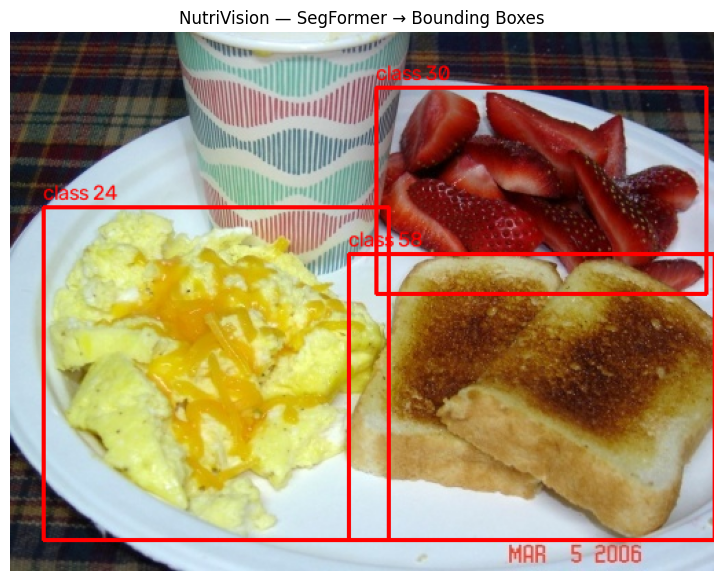

In [44]:
# ============================================================
# NUTRIVISION — TRAINED MODEL → FOOD REGIONS / BOXES
# ============================================================

import numpy as np
import tensorflow as tf
import cv2
from PIL import Image
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# USE THE VERIFIED MODEL
# ------------------------------------------------------------

model = verification_model

# ------------------------------------------------------------
# TAKE ONE DEVELOPMENT IMAGE
# ------------------------------------------------------------

image_path = (
    DATA_ROOT
    / "images"
    / "train"
    / dev_names[0]
)

mask_path = (
    DATA_ROOT
    / "masks"
    / "train"
    / dev_names[0].replace(".jpg", ".png")
)

print("Image:", image_path.name)

# ------------------------------------------------------------
# LOAD ORIGINAL IMAGE
# ------------------------------------------------------------

original = np.array(
    Image.open(image_path).convert("RGB")
)

original_h, original_w = original.shape[:2]

print("Original image shape:", original.shape)

# ------------------------------------------------------------
# PREPROCESS EXACTLY AS DURING TRAINING
# ------------------------------------------------------------

image = tf.convert_to_tensor(
    original,
    dtype=tf.float32
)

image = tf.image.resize(
    image,
    [512, 512],
    method="bilinear"
)

image = image / 255.0

MEAN = tf.constant(
    [0.485, 0.456, 0.406],
    dtype=tf.float32
)

STD = tf.constant(
    [0.229, 0.224, 0.225],
    dtype=tf.float32
)

image = (image - MEAN) / STD

image = tf.expand_dims(
    image,
    axis=0
)

# ------------------------------------------------------------
# INFERENCE
# ------------------------------------------------------------

logits = model(
    image,
    training=False
)

pred_mask = tf.argmax(
    logits,
    axis=-1,
    output_type=tf.int32
)[0]

pred_mask = pred_mask.numpy()

print("Predicted mask shape:", pred_mask.shape)
print(
    "Predicted classes:",
    np.unique(pred_mask)
)

# ------------------------------------------------------------
# RESIZE MASK BACK TO ORIGINAL IMAGE SIZE
# ------------------------------------------------------------

pred_mask_original = cv2.resize(
    pred_mask.astype(np.uint8),
    (original_w, original_h),
    interpolation=cv2.INTER_NEAREST
)

# ------------------------------------------------------------
# CREATE BOUNDING BOXES
#
# IMPORTANT:
# Background class 0 is ignored.
# Every predicted food class gets connected components.
# ------------------------------------------------------------

detections = []

for class_id in np.unique(pred_mask_original):

    class_id = int(class_id)

    if class_id == 0:
        continue

    binary_mask = (
        pred_mask_original == class_id
    ).astype(np.uint8)

    num_labels, labels, stats, centroids = (
        cv2.connectedComponentsWithStats(
            binary_mask,
            connectivity=8
        )
    )

    for component_id in range(1, num_labels):

        x = int(
            stats[component_id, cv2.CC_STAT_LEFT]
        )

        y = int(
            stats[component_id, cv2.CC_STAT_TOP]
        )

        w = int(
            stats[component_id, cv2.CC_STAT_WIDTH]
        )

        h = int(
            stats[component_id, cv2.CC_STAT_HEIGHT]
        )

        area = int(
            stats[component_id, cv2.CC_STAT_AREA]
        )

        # Preliminary noise filter.
        # This is NOT our final tuned value.
        if area < 100:
            continue

        detections.append({
            "class_id": class_id,
            "box": [
                x,
                y,
                x + w,
                y + h
            ],
            "area": area
        })

# ------------------------------------------------------------
# PRINT DETECTIONS
# ------------------------------------------------------------

print("\n===== DETECTIONS =====")

print("Number of regions:", len(detections))

for i, detection in enumerate(detections, start=1):

    print(
        f"{i}. "
        f"class_id={detection['class_id']} "
        f"box={detection['box']} "
        f"area={detection['area']}"
    )

# ------------------------------------------------------------
# VISUALIZE
# ------------------------------------------------------------

visual = original.copy()

for detection in detections:

    x1, y1, x2, y2 = detection["box"]
    class_id = detection["class_id"]

    cv2.rectangle(
        visual,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

    cv2.putText(
        visual,
        f"class {class_id}",
        (x1, max(y1 - 5, 15)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        1,
        cv2.LINE_AA
    )

plt.figure(figsize=(10, 7))
plt.imshow(visual)
plt.axis("off")
plt.title("NutriVision — SegFormer → Bounding Boxes")
plt.show()

In [45]:
# ============================================================
# NUTRIVISION — DEVELOPMENT POST-PROCESSING TUNING
# ============================================================

import numpy as np
import cv2
import tensorflow as tf
from PIL import Image
from pathlib import Path
import time

# ------------------------------------------------------------
# IMPORTANT
# Use the VERIFIED Epoch-8 model.
# No training / no gradients.
# ------------------------------------------------------------

model = verification_model

# Candidate connected-component area thresholds.
# These are post-processing parameters only.
AREA_THRESHOLDS = [20, 50, 100, 250, 500]

# Evaluate the full 500-image development set.
DEV_LIMIT = len(dev_names)

print("===== POST-PROCESSING TUNING =====")
print("Development images:", DEV_LIMIT)
print("Area thresholds   :", AREA_THRESHOLDS)
print("Model training    : NO")
print("Gradient updates  : NO")

MEAN = tf.constant(
    [0.485, 0.456, 0.406],
    dtype=tf.float32
)

STD = tf.constant(
    [0.229, 0.224, 0.225],
    dtype=tf.float32
)


# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------

def load_and_predict(name):
    """Load one original image and produce predicted mask."""

    image_path = (
        DATA_ROOT / "images" / "train" / name
    )

    mask_path = (
        DATA_ROOT / "masks" / "train"
        / name.replace(".jpg", ".png")
    )

    original = np.array(
        Image.open(image_path).convert("RGB")
    )

    h, w = original.shape[:2]

    # Same preprocessing used during training.
    image = tf.convert_to_tensor(
        original,
        dtype=tf.float32
    )

    image = tf.image.resize(
        image,
        [512, 512],
        method="bilinear"
    )

    image = image / 255.0
    image = (image - MEAN) / STD
    image = tf.expand_dims(image, 0)

    logits = model(
        image,
        training=False
    )

    pred = tf.argmax(
        logits,
        axis=-1,
        output_type=tf.int32
    )[0]

    pred = pred.numpy().astype(np.uint8)

    # Return prediction at original image resolution.
    pred = cv2.resize(
        pred,
        (w, h),
        interpolation=cv2.INTER_NEAREST
    )

    # Ground-truth FoodSeg103 mask.
    gt = np.array(
        Image.open(mask_path)
    ).astype(np.uint8)

    return pred, gt


def mask_to_boxes(mask, min_area):
    """
    Convert one semantic segmentation mask into
    class-level connected-component bounding boxes.
    """

    boxes = []

    for class_id in np.unique(mask):

        class_id = int(class_id)

        # Ignore background.
        if class_id == 0:
            continue

        binary = (
            mask == class_id
        ).astype(np.uint8)

        n, labels, stats, _ = (
            cv2.connectedComponentsWithStats(
                binary,
                connectivity=8
            )
        )

        for component_id in range(1, n):

            x = int(
                stats[
                    component_id,
                    cv2.CC_STAT_LEFT
                ]
            )

            y = int(
                stats[
                    component_id,
                    cv2.CC_STAT_TOP
                ]
            )

            w = int(
                stats[
                    component_id,
                    cv2.CC_STAT_WIDTH
                ]
            )

            h = int(
                stats[
                    component_id,
                    cv2.CC_STAT_HEIGHT
                ]
            )

            area = int(
                stats[
                    component_id,
                    cv2.CC_STAT_AREA
                ]
            )

            if area < min_area:
                continue

            boxes.append({
                "class_id": class_id,
                "box": (
                    x,
                    y,
                    x + w,
                    y + h
                ),
                "area": area
            })

    return boxes


def gt_class_boxes(mask):
    """
    Create one ground-truth box per class present.

    This matches the class-level bounding-box convention
    used by our FoodSeg103 conversion design.
    """

    boxes = []

    for class_id in np.unique(mask):

        class_id = int(class_id)

        if class_id == 0:
            continue

        ys, xs = np.where(
            mask == class_id
        )

        if len(xs) == 0:
            continue

        boxes.append({
            "class_id": class_id,
            "box": (
                int(xs.min()),
                int(ys.min()),
                int(xs.max()) + 1,
                int(ys.max()) + 1
            )
        })

    return boxes


def box_iou(box_a, box_b):

    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    iw = max(0, ix2 - ix1)
    ih = max(0, iy2 - iy1)

    intersection = iw * ih

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)

    union = area_a + area_b - intersection

    if union <= 0:
        return 0.0

    return intersection / union


# ------------------------------------------------------------
# EVALUATION
# ------------------------------------------------------------

results = {
    threshold: {
        "pred_boxes": 0,
        "matched": 0,
        "iou_sum": 0.0
    }
    for threshold in AREA_THRESHOLDS
}

start_time = time.time()

for index, name in enumerate(
    dev_names[:DEV_LIMIT],
    start=1
):

    pred_mask, gt_mask = load_and_predict(name)

    gt_boxes = gt_class_boxes(gt_mask)

    for threshold in AREA_THRESHOLDS:

        pred_boxes = mask_to_boxes(
            pred_mask,
            threshold
        )

        results[threshold]["pred_boxes"] += len(
            pred_boxes
        )

        # Match predictions to GT boxes by class.
        # Each GT class receives its highest-IoU
        # prediction from that class.
        for gt in gt_boxes:

            candidates = [
                p for p in pred_boxes
                if p["class_id"] == gt["class_id"]
            ]

            if not candidates:
                continue

            best_iou = max(
                box_iou(
                    p["box"],
                    gt["box"]
                )
                for p in candidates
            )

            if best_iou > 0:
                results[threshold]["matched"] += 1
                results[threshold]["iou_sum"] += best_iou

    if index % 25 == 0:

        elapsed = time.time() - start_time

        print(
            f"Processed {index}/{DEV_LIMIT} "
            f"images | "
            f"{elapsed / 60:.1f} min"
        )


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("\n===== POST-PROCESSING RESULTS =====")

for threshold in AREA_THRESHOLDS:

    r = results[threshold]

    mean_matched_iou = (
        r["iou_sum"] / r["matched"]
        if r["matched"] > 0
        else 0.0
    )

    print(
        f"\nmin_area = {threshold}"
    )

    print(
        "  Predicted boxes :",
        r["pred_boxes"]
    )

    print(
        "  Matched boxes   :",
        r["matched"]
    )

    print(
        "  Mean matched IoU:",
        f"{mean_matched_iou:.4f}"
    )

print(
    "\nTotal time:",
    f"{(time.time() - start_time) / 60:.2f} minutes"
)

print("\n===== POST-PROCESSING TUNING COMPLETE =====")

===== POST-PROCESSING TUNING =====
Development images: 500
Area thresholds   : [20, 50, 100, 250, 500]
Model training    : NO
Gradient updates  : NO
Processed 25/500 images | 0.5 min
Processed 50/500 images | 1.0 min
Processed 75/500 images | 1.6 min
Processed 100/500 images | 1.9 min
Processed 125/500 images | 2.3 min
Processed 150/500 images | 2.6 min
Processed 175/500 images | 3.0 min
Processed 200/500 images | 3.5 min
Processed 225/500 images | 3.9 min
Processed 250/500 images | 4.2 min
Processed 275/500 images | 4.7 min
Processed 300/500 images | 5.0 min
Processed 325/500 images | 5.4 min
Processed 350/500 images | 5.8 min
Processed 375/500 images | 6.2 min
Processed 400/500 images | 6.5 min
Processed 425/500 images | 7.0 min
Processed 450/500 images | 7.4 min
Processed 475/500 images | 7.8 min
Processed 500/500 images | 8.2 min

===== POST-PROCESSING RESULTS =====

min_area = 20
  Predicted boxes : 7355
  Matched boxes   : 1403
  Mean matched IoU: 0.6500

min_area = 50
  Predicte

In [ ]:
# ============================================================
# NUTRIVISION — PROPER BOX-LEVEL POST-PROCESSING EVALUATION
# ============================================================

import numpy as np
import cv2
import tensorflow as tf
from PIL import Image
import time

# ------------------------------------------------------------
# FIXED MODEL — NO TRAINING
# ------------------------------------------------------------

model = verification_model

IOU_THRESHOLD = 0.50
AREA_THRESHOLDS = [20, 50, 100, 250, 500]

MEAN = tf.constant(
    [0.485, 0.456, 0.406],
    dtype=tf.float32
)

STD = tf.constant(
    [0.229, 0.224, 0.225],
    dtype=tf.float32
)


# ------------------------------------------------------------
# ONE IMAGE INFERENCE
# ------------------------------------------------------------

def load_and_predict_cpu(name):

    image_path = (
        DATA_ROOT / "images" / "train" / name
    )

    mask_path = (
        DATA_ROOT / "masks" / "train"
        / name.replace(".jpg", ".png")
    )

    original = np.array(
        Image.open(image_path).convert("RGB")
    )

    h, w = original.shape[:2]

    image = tf.convert_to_tensor(
        original,
        dtype=tf.float32
    )

    image = tf.image.resize(
        image,
        [512, 512],
        method="bilinear"
    )

    image = image / 255.0
    image = (image - MEAN) / STD
    image = tf.expand_dims(image, 0)

    # Explicit CPU inference.
    with tf.device("/CPU:0"):
        logits = model(
            image,
            training=False
        )

    pred = tf.argmax(
        logits,
        axis=-1,
        output_type=tf.int32
    )[0]

    pred = pred.numpy().astype(np.uint8)

    pred = cv2.resize(
        pred,
        (w, h),
        interpolation=cv2.INTER_NEAREST
    )

    gt = np.array(
        Image.open(mask_path)
    ).astype(np.uint8)

    return pred, gt


# ------------------------------------------------------------
# PREDICTED MASK → BOXES
# ------------------------------------------------------------

def mask_to_boxes(mask, min_area):

    boxes = []

    for class_id in np.unique(mask):

        class_id = int(class_id)

        if class_id == 0:
            continue

        binary = (
            mask == class_id
        ).astype(np.uint8)

        n, labels, stats, _ = (
            cv2.connectedComponentsWithStats(
                binary,
                connectivity=8
            )
        )

        for component_id in range(1, n):

            x = int(
                stats[
                    component_id,
                    cv2.CC_STAT_LEFT
                ]
            )

            y = int(
                stats[
                    component_id,
                    cv2.CC_STAT_TOP
                ]
            )

            w = int(
                stats[
                    component_id,
                    cv2.CC_STAT_WIDTH
                ]
            )

            h = int(
                stats[
                    component_id,
                    cv2.CC_STAT_HEIGHT
                ]
            )

            area = int(
                stats[
                    component_id,
                    cv2.CC_STAT_AREA
                ]
            )

            if area < min_area:
                continue

            boxes.append({
                "class_id": class_id,
                "box": (
                    x,
                    y,
                    x + w,
                    y + h
                )
            })

    return boxes


# ------------------------------------------------------------
# GROUND-TRUTH MASK → CLASS-LEVEL BOXES
# ------------------------------------------------------------

def gt_class_boxes(mask):

    boxes = []

    for class_id in np.unique(mask):

        class_id = int(class_id)

        if class_id == 0:
            continue

        ys, xs = np.where(
            mask == class_id
        )

        if len(xs) == 0:
            continue

        boxes.append({
            "class_id": class_id,
            "box": (
                int(xs.min()),
                int(ys.min()),
                int(xs.max()) + 1,
                int(ys.max()) + 1
            )
        })

    return boxes


# ------------------------------------------------------------
# BOX IoU
# ------------------------------------------------------------

def box_iou(a, b):

    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    iw = max(0, ix2 - ix1)
    ih = max(0, iy2 - iy1)

    intersection = iw * ih

    area_a = (
        max(0, ax2 - ax1)
        * max(0, ay2 - ay1)
    )

    area_b = (
        max(0, bx2 - bx1)
        * max(0, by2 - by1)
    )

    union = area_a + area_b - intersection

    if union <= 0:
        return 0.0

    return intersection / union


# ------------------------------------------------------------
# ONE-TO-ONE CLASS-AWARE MATCHING
# ------------------------------------------------------------

def match_boxes(pred_boxes, gt_boxes, iou_threshold):

    candidates = []

    for pi, pred in enumerate(pred_boxes):

        for gi, gt in enumerate(gt_boxes):

            # A prediction can only match the same class.
            if pred["class_id"] != gt["class_id"]:
                continue

            iou = box_iou(
                pred["box"],
                gt["box"]
            )

            if iou >= iou_threshold:

                candidates.append(
                    (iou, pi, gi)
                )

    # Highest IoU matches first.
    candidates.sort(
        reverse=True,
        key=lambda x: x[0]
    )

    used_predictions = set()
    used_ground_truth = set()

    matches = []

    for iou, pi, gi in candidates:

        if pi in used_predictions:
            continue

        if gi in used_ground_truth:
            continue

        used_predictions.add(pi)
        used_ground_truth.add(gi)

        matches.append(
            (pi, gi, iou)
        )

    tp = len(matches)

    fp = len(pred_boxes) - tp
    fn = len(gt_boxes) - tp

    matched_iou = (
        sum(x[2] for x in matches) / tp
        if tp > 0
        else 0.0
    )

    return tp, fp, fn, matched_iou


# ------------------------------------------------------------
# EVALUATE ALL THRESHOLDS
# ------------------------------------------------------------

totals = {
    threshold: {
        "tp": 0,
        "fp": 0,
        "fn": 0,
        "iou_sum": 0.0
    }
    for threshold in AREA_THRESHOLDS
}

start_time = time.time()

print("===== PROPER BOX-LEVEL EVALUATION =====")
print("Images       :", len(dev_names))
print("IoU threshold:", IOU_THRESHOLD)
print("Area values  :", AREA_THRESHOLDS)
print("Device       : CPU")
print("Training     : NO")
print()

for index, name in enumerate(
    dev_names,
    start=1
):

    pred_mask, gt_mask = load_and_predict_cpu(
        name
    )

    gt_boxes = gt_class_boxes(
        gt_mask
    )

    for threshold in AREA_THRESHOLDS:

        pred_boxes = mask_to_boxes(
            pred_mask,
            threshold
        )

        tp, fp, fn, matched_iou = match_boxes(
            pred_boxes,
            gt_boxes,
            IOU_THRESHOLD
        )

        totals[threshold]["tp"] += tp
        totals[threshold]["fp"] += fp
        totals[threshold]["fn"] += fn
        totals[threshold]["iou_sum"] += (
            matched_iou * tp
        )

    if index % 25 == 0:

        elapsed = time.time() - start_time

        print(
            f"Processed {index}/{len(dev_names)} "
            f"| {elapsed / 60:.1f} min"
        )


# ------------------------------------------------------------
# FINAL METRICS
# ------------------------------------------------------------

print("\n===== PROPER POST-PROCESSING METRICS =====")

for threshold in AREA_THRESHOLDS:

    r = totals[threshold]

    tp = r["tp"]
    fp = r["fp"]
    fn = r["fn"]

    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    mean_iou = (
        r["iou_sum"] / tp
        if tp > 0
        else 0.0
    )

    print(
        f"\nmin_area = {threshold}"
    )

    print(
        f"  TP              : {tp}"
    )

    print(
        f"  FP              : {fp}"
    )

    print(
        f"  FN              : {fn}"
    )

    print(
        f"  Precision       : {precision:.4f}"
    )

    print(
        f"  Recall          : {recall:.4f}"
    )

    print(
        f"  F1              : {f1:.4f}"
    )

    print(
        f"  Mean matched IoU: {mean_iou:.4f}"
    )


print(
    "\nTotal time:",
    f"{(time.time() - start_time) / 60:.2f} minutes"
)

print("\n===== EVALUATION COMPLETE =====")

===== PROPER BOX-LEVEL EVALUATION =====
Images       : 500
IoU threshold: 0.5
Area values  : [20, 50, 100, 250, 500]
Device       : CPU
Training     : NO

Processed 25/500 | 1.7 min
Processed 50/500 | 3.3 min
Processed 75/500 | 5.1 min
Processed 100/500 | 6.6 min
Processed 125/500 | 8.1 min
Processed 150/500 | 9.6 min
